<a href="https://colab.research.google.com/github/OttonielCA/AI_TP1/blob/main/gwa_t_13_materna_data_reading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Group of Machines

### Dataset Used -
 http://gwa.ewi.tudelft.nl/datasets/gwa-t-13-materna

In [9]:
#connect to drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

Ottoniel

In [10]:
#List of input data folder (can add Materna-Trace-1, Materna-Trace-2, Materna-Trace-3)
Materna_Traces = ["/content/gdrive/MyDrive/Colab Notebooks/AI_3/DATA/Materna-Trace-1"]

Daniel

Sean

Flavio

In [7]:
def readInputData(paths):
    for path in paths:
        # Get all csv files in the directory
        all_files = glob.glob(path + "/*.csv")
        print(f"Found {len(all_files)} CSV files")

        data = []
        for filename in all_files:
            try:
                # Read each CSV file
                df = pd.read_csv(filename, delimiter=';', index_col=None, header=0)

                # Clean column names
                df.columns = df.columns.str.replace('\t', '')  # Remove tabs
                df.columns = df.columns.str.strip()            # Remove leading/trailing whitespace

                data.append(df)
            except Exception as e:
                print(f"Error reading file {filename}: {str(e)}")

        print(f"Successfully read {len(data)} files")
        dataframe = pd.concat(data, axis=0, ignore_index=True)
    return dataframe

In [11]:
#call the function
inputData = readInputData(Materna_Traces)

Found 520 CSV files
Successfully read 520 files


In [62]:
 #first 5 rows of data
 inputData.head()

,Timestamp,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],CPU usage [%],Memory capacity provisioned [KB],Memory usage [KB],Memory usage [%],Disk read throughput [KB/s],Disk write throughput [KB/s],Disk size [GB],Network received throughput [KB/s],Network transmitted throughput [KB/s]
0,05.11.2015 00:00:00,1,0,7,"0,39",4194304,0,0,0.0,0.0,24,0.0,0.0
1,05.11.2015 00:05:00,1,0,8,"0,41",4194304,0,0,0.0,1.0,24,0.0,0.0
2,05.11.2015 00:10:00,1,0,8,"0,4",4194304,24746,"0,59",0.0,0.0,24,0.0,0.0
3,05.11.2015 00:15:00,1,0,8,"0,4",4194304,21810,"0,52",0.0,0.0,24,0.0,0.0
4,05.11.2015 00:20:00,1,0,8,"0,4",4194304,66689,"1,59",0.0,0.0,24,0.0,0.0


In [14]:
#number of rows and columns in data
inputData.shape
df = inputData

In [15]:
df.describe()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
count,4.173593e+06,4.173593e+06,4.173593e+06,4.173593e+06,4.173593e+06,4.173510e+06,4.173510e+06,4.173592e+06,4.173592e+06
mean,2.516428e+00,3.957039e+00,2.554214e+02,8.338714e+06,6.916890e+05,6.195813e+02,2.246222e+02,1.186189e+02,1.609239e+02
std,1.553927e+00,8.993531e+01,6.585926e+02,9.792384e+06,1.148770e+06,7.710081e+03,2.724763e+03,1.344712e+03,1.658470e+03
min,1.000000e+00,0.000000e+00,1.000000e+00,2.621440e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,0.000000e+00,2.300000e+01,4.194304e+06,7.382000e+04,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00,7.000000e+01,8.388608e+06,2.132800e+05,0.000000e+00,7.000000e+00,1.000000e+00,1.000000e+00
75%,2.000000e+00,0.000000e+00,1.700000e+02,8.388608e+06,8.506050e+05,0.000000e+00,3.700000e+01,1.400000e+01,1.500000e+01
max,8.000000e+00,2.048000e+03,1.722800e+04,1.342177e+08,2.038180e+07,6.739620e+05,6.739850e+05,1.213930e+05,1.404060e+05


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4173593 entries, 0 to 4173592
Data columns (total 13 columns):
 #   Column                                 Dtype  
---  ------                                 -----  
 0   Timestamp                              object 
 1   CPU cores                              int64  
 2   CPU capacity provisioned [MHZ]         int64  
 3   CPU usage [MHZ]                        int64  
 4   CPU usage [%]                          object 
 5   Memory capacity provisioned [KB]       int64  
 6   Memory usage [KB]                      int64  
 7   Memory usage [%]                       object 
 8   Disk read throughput [KB/s]            float64
 9   Disk write throughput [KB/s]           float64
 10  Disk size [GB]                         object 
 11  Network received throughput [KB/s]     float64
 12  Network transmitted throughput [KB/s]  float64
dtypes: float64(4), int64(5), object(4)
memory usage: 413.9+ MB


# **Data Visualization**

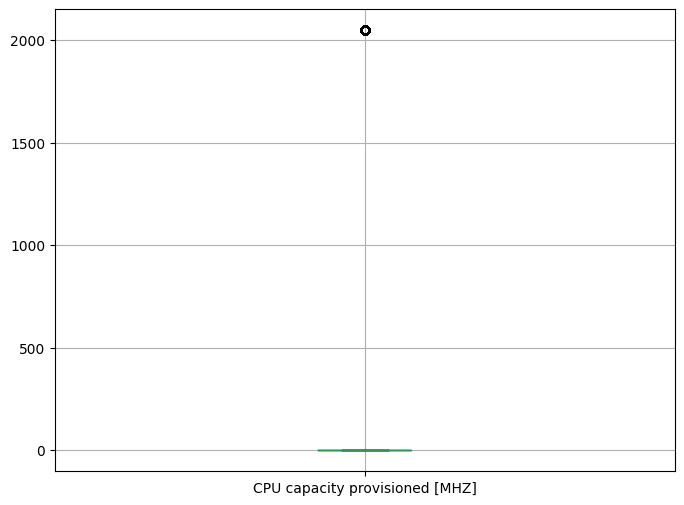

In [17]:
plt.figure(figsize = (8,6))
df.boxplot(column = ['CPU capacity provisioned [MHZ]'])
plt.show()

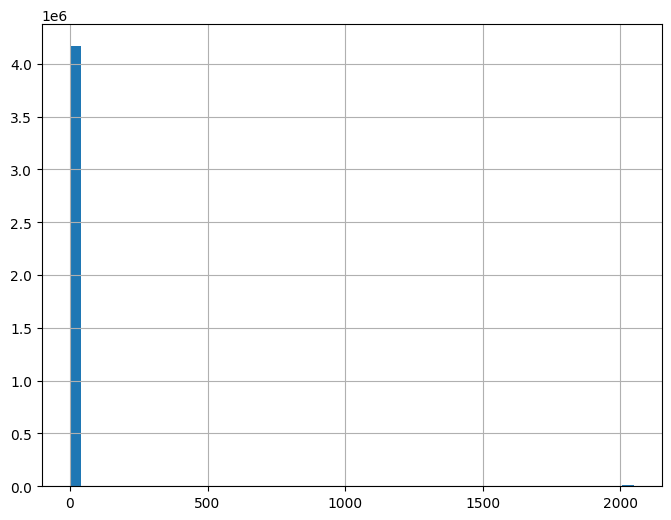

In [18]:
plt.figure(figsize = (8,6))
df['CPU capacity provisioned [MHZ]'].hist(bins = 50)
plt.show()

In [19]:
df['CPU capacity provisioned [MHZ]'].value_counts(0)

,count
CPU capacity provisioned [MHZ],
0,4165529
2048,8064


In [20]:
df['CPU cores'].value_counts()

,count
CPU cores,
2,2668708
4,627684
1,592377
8,176536
6,108288


In [21]:
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from numpy import unique
from numpy import where

In [47]:
def dbscan(eps, min_samples, data, start, end):
    # define the model
    model = DBSCAN(eps=eps, min_samples=min_samples)  # Correction ici
    # fit model and predict clusters
    yhat = model.fit_predict(data)
    # retrieve unique clusters
    clusters = unique(yhat)
    # create scatter plot for samples from each cluster
    for cluster in clusters:
        # get row indexes for samples with this cluster
        row_ix = where(yhat == cluster)
        # create scatter of these samples
        plt.scatter(data[row_ix, start], data[row_ix, end])
        plt.title("eps="+str(eps)+"    "+"min_samples="+str(min_samples))
    # show the plot
    plt.show()

In [23]:
df.describe()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
count,4.173593e+06,4.173593e+06,4.173593e+06,4.173593e+06,4.173593e+06,4.173510e+06,4.173510e+06,4.173592e+06,4.173592e+06
mean,2.516428e+00,3.957039e+00,2.554214e+02,8.338714e+06,6.916890e+05,6.195813e+02,2.246222e+02,1.186189e+02,1.609239e+02
std,1.553927e+00,8.993531e+01,6.585926e+02,9.792384e+06,1.148770e+06,7.710081e+03,2.724763e+03,1.344712e+03,1.658470e+03
min,1.000000e+00,0.000000e+00,1.000000e+00,2.621440e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,0.000000e+00,2.300000e+01,4.194304e+06,7.382000e+04,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00,7.000000e+01,8.388608e+06,2.132800e+05,0.000000e+00,7.000000e+00,1.000000e+00,1.000000e+00
75%,2.000000e+00,0.000000e+00,1.700000e+02,8.388608e+06,8.506050e+05,0.000000e+00,3.700000e+01,1.400000e+01,1.500000e+01
max,8.000000e+00,2.048000e+03,1.722800e+04,1.342177e+08,2.038180e+07,6.739620e+05,6.739850e+05,1.213930e+05,1.404060e+05


In [26]:
df['CPU capacity provisioned [MHZ]'].value_counts(0)

,count
CPU capacity provisioned [MHZ],
0,4165529
2048,8064


In [31]:
df['CPU usage [MHZ]'].value_counts()

,count
CPU usage [MHZ],
19,77764
18,76972
15,74832
24,71782
13,71299
...,...
7060,1
3958,1
7494,1


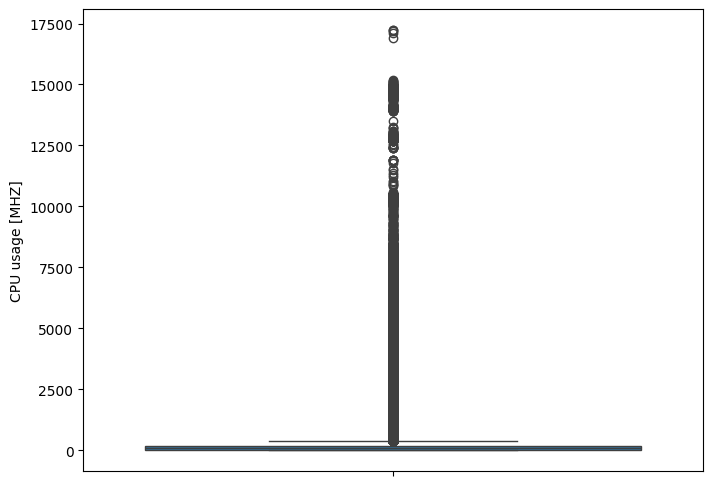

In [28]:
plt.figure(figsize = (8,6))
sns.boxplot(df['CPU usage [MHZ]'])
plt.show()

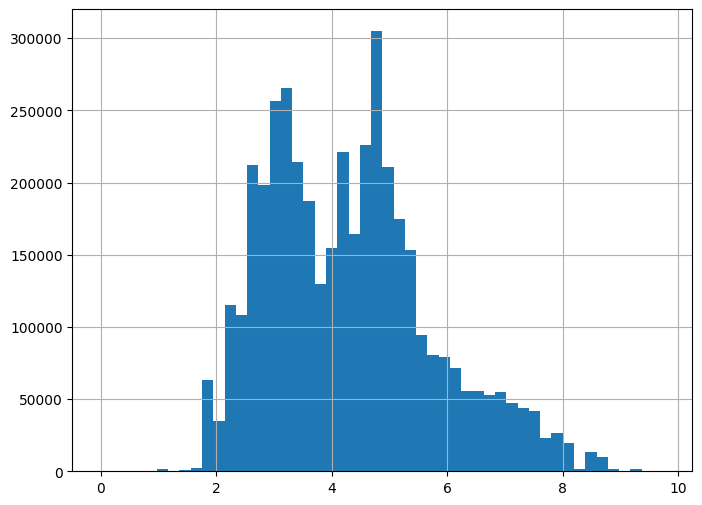

In [32]:
plt.figure(figsize = (8,6))
np.log(df['CPU usage [MHZ]']).hist(bins = 50)#this feature was very robust earlier. By taking the log of the feature we are
                                            # getting a normalized curve.
plt.show()

In [33]:
df['Memory capacity provisioned [KB]'].value_counts()

,count
Memory capacity provisioned [KB],
8388608,1116340
4194304,1000041
2097152,836118
16777216,489756
12582912,216148
6291456,150048
20971520,97920
1048576,60480
10485760,58464


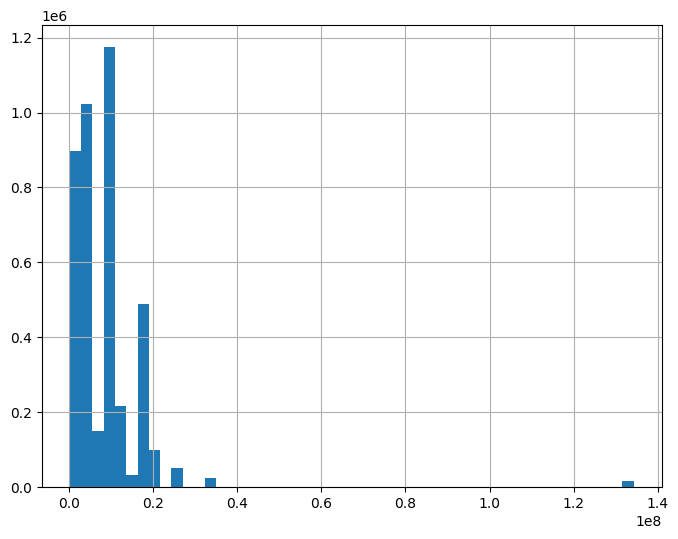

In [34]:
plt.figure(figsize = (8,6))
df['Memory capacity provisioned [KB]'].hist(bins = 50)
plt.show()

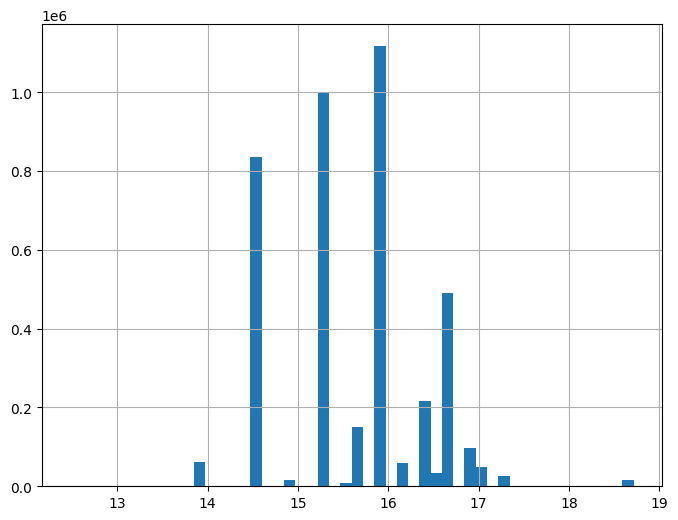

In [35]:
plt.figure(figsize = (8,6))
np.log(df['Memory capacity provisioned [KB]']).hist(bins = 50)
plt.show()

In [36]:
np.log(df['Memory capacity provisioned [KB]']).describe()

,Memory capacity provisioned [KB]
count,4.173593e+06
mean,1.561731e+01
std,7.798942e-01
min,1.247665e+01
25%,1.524924e+01
50%,1.594239e+01
75%,1.594239e+01
max,1.871497e+01


In [ ]:
df.describe()

,CPU cores,CPU capacity provisioned [MHZ],CPU usage [MHZ],Memory capacity provisioned [KB],Memory usage [KB],Disk read throughput [KB/s],Disk write throughput [KB/s],Network received throughput [KB/s],Network transmitted throughput [KB/s]
count,5.329730e+06,5.329730e+06,5.329730e+06,5.329730e+06,5.329730e+06,5.329730e+06,5.329730e+06,5.329730e+06,5.329730e+06
mean,2.637684e+00,3.982851e+00,2.596080e+02,8.873539e+06,7.058790e+05,5.352213e+02,1.790060e+02,9.293955e+01,1.396144e+02
std,1.628044e+00,9.022759e+01,6.365165e+02,1.009509e+07,1.135087e+06,6.929329e+03,1.533413e+03,9.121657e+02,1.434829e+03
min,1.000000e+00,0.000000e+00,1.000000e+00,1.048576e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,0.000000e+00,2.400000e+01,4.194304e+06,8.053100e+04,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,0.000000e+00,6.900000e+01,8.388608e+06,2.231370e+05,0.000000e+00,8.000000e+00,1.000000e+00,1.000000e+00
75%,4.000000e+00,0.000000e+00,1.840000e+02,1.048576e+07,8.719960e+05,0.000000e+00,3.900000e+01,1.500000e+01,1.700000e+01
max,8.000000e+00,2.048000e+03,1.552800e+04,1.342177e+08,2.365252e+07,3.779170e+05,1.449880e+05,1.126790e+05,1.142190e+05


In [37]:
df['Memory usage [KB]'].value_counts()

,count
Memory usage [KB],
0,251773
41524,23623
55365,19308
65431,18702
83047,17720
...,...
320025,1
3343699,1
15586034,1


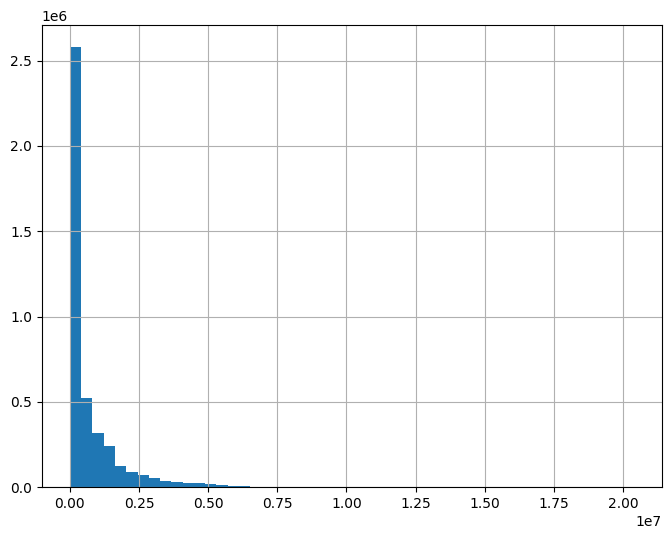

In [38]:
plt.figure(figsize = (8,6))
df['Memory usage [KB]'].hist(bins = 50)
plt.show()

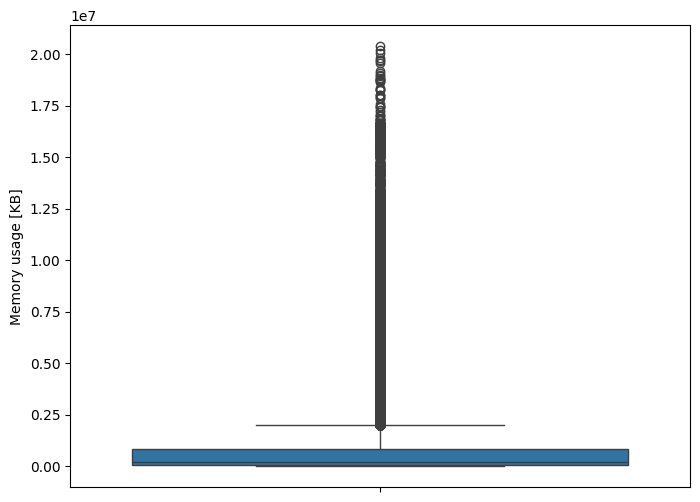

In [39]:
plt.figure(figsize = (8,6))
sns.boxplot(df['Memory usage [KB]'])
plt.show()

In [ ]:
df['Disk read throughput [KB/s]'].value_counts()

0         4500772
1          102974
2           50511
3           36984
4           28486
           ...   
26192           1
35844           1
191561          1
13914           1
79858           1
Name: Disk read throughput [KB/s], Length: 43857, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5329730 entries, 0 to 5329729
Data columns (total 13 columns):
 #   Column                                 Dtype 
---  ------                                 ----- 
 0   Timestamp                              object
 1   CPU cores                              int64 
 2   CPU capacity provisioned [MHZ]         int64 
 3   CPU usage [MHZ]                        int64 
 4   CPU usage [%]                          object
 5   Memory capacity provisioned [KB]       int64 
 6   Memory usage [KB]                      int64 
 7   Memory usage [%]                       object
 8   Disk read throughput [KB/s]            int64 
 9   Disk write throughput [KB/s]           int64 
 10  Disk size [GB]                         object
 11  Network received throughput [KB/s]     int64 
 12  Network transmitted throughput [KB/s]  int64 
dtypes: int64(9), object(4)
memory usage: 528.6+ MB


In [ ]:
df['CPU usage [%]'].value_counts()

0,23     55912
0,22     51117
0,21     50040
0,18     45015
0,41     44539
         ...  
80,79        1
71,29        1
82,37        1
67,87        1
90,19        1
Name: CPU usage [%], Length: 9298, dtype: int64

In [ ]:
df['Disk size [GB]'].value_counts()

22              665298
24              353654
438             216576
58              198790
34              190366
                 ...  
1274              1432
114,38671875      1147
522                582
4382               576
6392               288
Name: Disk size [GB], Length: 154, dtype: int64

In [41]:
df = df.drop('Timestamp', axis=1)
#replace , with . in % values
df = df.replace(to_replace=r',', value='.', regex=True)

# **Analysing specific set of metrics for identifying the best set of features:**



*   CPU usagelog
*   Memory usage [%]
*   Disk read throughput [KB/s]
*   Disk write throughput [KB/s]



In [42]:
data = df[["CPU cores", "CPU capacity provisioned [MHZ]", "CPU usage [MHZ]",
                  "Memory capacity provisioned [KB]",
                  "Memory usage [KB]", "Disk read throughput [KB/s]",
                  "Disk write throughput [KB/s]", "Disk size [GB]",
                  "Network received throughput [KB/s]",
                  "Network transmitted throughput [KB/s]"]]

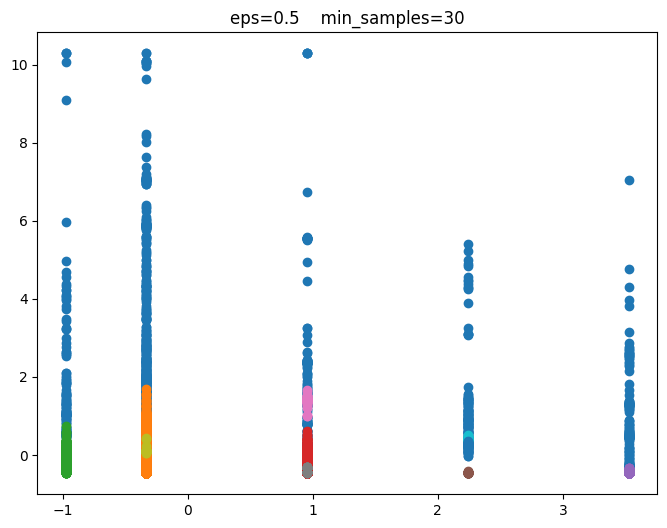

In [48]:
machine_data_std = StandardScaler().fit_transform(df)
#randomly choose ten thousand samples
machine_data_index = np.random.randint(1, df.shape[0], 10000)
#Apply DBSCAN algorithm
plt.figure(figsize = (8,6))
dbscan(eps=0.5, min_samples=30, data=machine_data_std[machine_data_index], start=0, end=3)
plt.show()

In [49]:
df['CPU usagelog'] = np.log(df['CPU usage [MHZ]'])

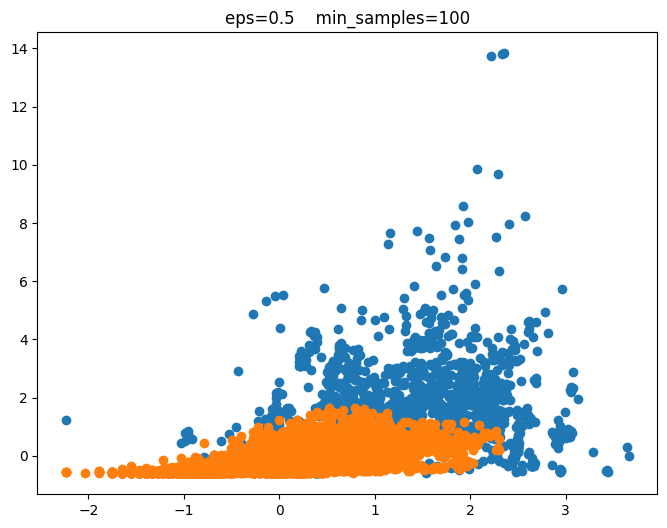

In [50]:
cpu_mem_disk_data = df[['CPU capacity provisioned [MHZ]', 'CPU usagelog', 'Memory capacity provisioned [KB]',
       'Memory usage [KB]', 'Disk read throughput [KB/s]',
       'Disk write throughput [KB/s]', 'Disk size [GB]']]
#standard scale data
cpu_mem_disk_data_std = StandardScaler().fit_transform(cpu_mem_disk_data)
#randomly choose ten thousand samples
machine_data_index = np.random.randint(1, df.shape[0], 10000)
#Apply DBSCAN algorithm
plt.figure(figsize = (8,6))
dbscan(eps=0.5, min_samples=100, data=cpu_mem_disk_data_std[machine_data_index], start=1, end=3)
plt.show()

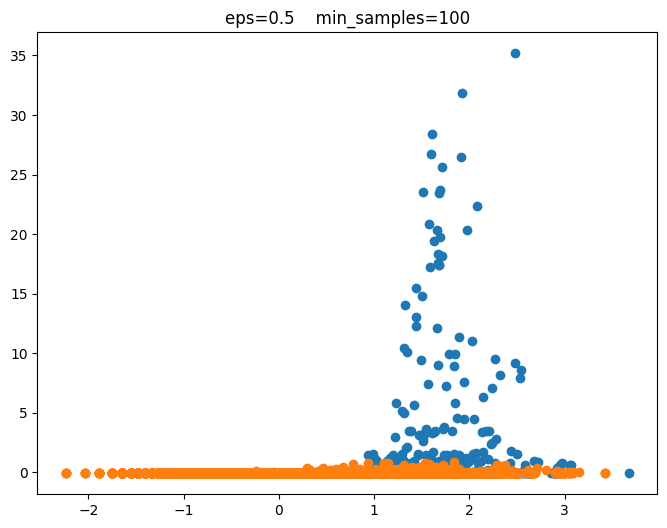

In [51]:
cpu_mem_disk_NW_use_data = df[['CPU usagelog',
                                   'Disk read throughput [KB/s]',
                                   'Disk write throughput [KB/s]']]
#standard scale data
cpu_mem_disk_NW_use_data_std = StandardScaler().fit_transform(cpu_mem_disk_NW_use_data)
#randomly choose ten thousand samples
machine_data_index = np.random.randint(1, df.shape[0], 10000)
#Apply DBSCAN algorithm
plt.figure(figsize = (8,6))
dbscan(eps=0.5, min_samples=100, data=cpu_mem_disk_NW_use_data_std[machine_data_index], start=0, end=1)
plt.show()

In [52]:
from sklearn.cluster import AffinityPropagation
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import Birch
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import MeanShift
from sklearn.cluster import SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.cluster import OPTICS

# **COMPARING DIFFERENT ALGORITHMS**

*   KMeans
*   DBSCAN
*   Agglomerative Clustering
*   Mini Batch KMeans
*   Mean Shift
*   OPTICS







# KMeans
Kmeans algorithm is an iterative algorithm that tries to partition the dataset into Kpre-defined distinct non-overlapping subgroups (clusters) where each data point belongs to only one group. It assigns data points to a cluster such that the sum of the squared distance between the data points and the cluster’s centroid (arithmetic mean of all the data points that belong to that cluster) is at the minimum.

In [53]:
from sklearn.cluster import KMeans
def score(data,n_c):
  kmeans_model = KMeans(n_clusters=n_c, random_state=1).fit(data)
  labels = kmeans_model.labels_
  x = metrics.silhouette_score(data, labels, metric='euclidean')
  print("Score for ",n_c," clusters: ",x)
score(cpu_mem_disk_NW_use_data_std[machine_data_index],2)
score(cpu_mem_disk_NW_use_data_std[machine_data_index],3)
score(cpu_mem_disk_NW_use_data_std[machine_data_index],4)

Score for  2  clusters:  0.5147406332788322
Score for  3  clusters:  0.5473187537087214
Score for  4  clusters:  0.5633722803405422


# DBSCAN
Based on a set of points (let’s think in a bidimensional space as exemplified in the figure), DBSCAN groups together points that are close to each other based on a distance measurement (usually Euclidean distance) and a minimum number of points. It also marks as outliers the points that are in low-density regions.

In [54]:
def dbscore(data,x):
  db = DBSCAN(eps=x, min_samples=100).fit(cpu_mem_disk_NW_use_data_std[machine_data_index])
  labels = db.labels_
  x = metrics.silhouette_score(data, labels, metric='euclidean')
  print("Score for dbscan: ",x)
dbscore(cpu_mem_disk_NW_use_data_std[machine_data_index],0.2)
dbscore(cpu_mem_disk_NW_use_data_std[machine_data_index],0.5)
dbscore(cpu_mem_disk_NW_use_data_std[machine_data_index],2)

Score for dbscan:  0.7344412964484334
Score for dbscan:  0.8056190857976008
Score for dbscan:  0.8980164008105201


# Agglomerative Clustering
The agglomerative clustering is the most common type of hierarchical clustering used to group objects in clusters based on their similarity. It's also known as AGNES (Agglomerative Nesting). The algorithm starts by treating each object as a singleton cluster.

In [55]:
def aggscore(data,damp):
  model = AgglomerativeClustering(n_clusters=damp)
  # fit the model
  model.fit(data)
  labels = model.labels_
  x = metrics.silhouette_score(data, labels, metric='euclidean')
  print("Score for Agglomerative Clustering with ",damp," clusters: ",x)
aggscore(cpu_mem_disk_NW_use_data_std[machine_data_index],2)
aggscore(cpu_mem_disk_NW_use_data_std[machine_data_index],3)
aggscore(cpu_mem_disk_NW_use_data_std[machine_data_index],4)

Score for Agglomerative Clustering with  2  clusters:  0.9430384109112405
Score for Agglomerative Clustering with  3  clusters:  0.5358256675905292
Score for Agglomerative Clustering with  4  clusters:  0.5541108295783226


# Mini_Batch_KMeans
Mini Batch K-means algorithm‘s main idea is to use small random batches of data of a fixed size, so they can be stored in memory. Each iteration a new random sample from the dataset is obtained and used to update the clusters and this is repeated until convergence. Each mini batch updates the clusters using a convex combination of the values of the prototypes and the data, applying a learning rate that decreases with the number of iterations.

In [56]:
def minbatchkmeans_score(data,n):
  model = MiniBatchKMeans(n)
  # fit the model
  model.fit(data)
  # assign a cluster to each example
  labels = model.labels_
  x = metrics.silhouette_score(data, labels,metric = 'euclidean')
  print("Score for Mini_batch_kmeans Clustering with ",n," clusters: ",x)
minbatchkmeans_score(cpu_mem_disk_NW_use_data_std[machine_data_index],2)
minbatchkmeans_score(cpu_mem_disk_NW_use_data_std[machine_data_index],3)
minbatchkmeans_score(cpu_mem_disk_NW_use_data_std[machine_data_index],4)

Score for Mini_batch_kmeans Clustering with  2  clusters:  0.5147017304377443
Score for Mini_batch_kmeans Clustering with  3  clusters:  0.5499405058497913
Score for Mini_batch_kmeans Clustering with  4  clusters:  0.4916558213819893


# Mean Shifting
Mean shift is a non-parametric feature-space analysis technique for locating the maxima of a density function, a so-called mode-seeking algorithm

In [57]:
def shift_score(data):
  model = MeanShift()
  # fit the model
  model.fit(data)
  # assign a cluster to each example
  labels = model.labels_
  x = metrics.silhouette_score(data, labels,metric = 'euclidean')
  print("Score for MeanShift: ",x)
shift_score(cpu_mem_disk_NW_use_data_std[machine_data_index])

Score for MeanShift:  0.5311488195997924


# OPTICS
Ordering points to identify the clustering structure (OPTICS) is an algorithm for finding density-based clusters in spatial data. Its basic idea is similar to DBSCAN, but it addresses one of DBSCAN's major weaknesses: the problem of detecting meaningful clusters in data of varying density. To do so, the points of the database are (linearly) ordered such that spatially closest points become neighbors in the ordering. Additionally, a special distance is stored for each point that represents the density that must be accepted for a cluster so that both points belong to the same cluster.

In [61]:
def opticscore(data, x):
    model = OPTICS(min_samples=x, max_eps=10).fit(data)
    labels = model.labels_
    score = metrics.silhouette_score(data, labels, metric='euclidean')
    print("Score for optics: ", score)

# Appel de la fonction
opticscore(cpu_mem_disk_NW_use_data_std[machine_data_index], 0.2)

Score for optics:  0.9475273053616348


# **CONCLUSION**

OPTICS algorithm gave the best results among all the algorithms. We can conclude that OPTICS is the best choice for the given dataset.



